In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import json
import torch
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from src.cnn_lstm.cnn_lstm_v3 import CNNLSTMV3
from src.XAI.rise import RISE
from src.rwf2000 import RWF2000Dataset
from src.config import DATASET_ROOT
from src.config import CHECKPOINT_DIR
from src.XAI.plotting_functions import plot_gradcam_over_rgb, plot_single_frame_gradcam, animate_saliency_over_rgb
from scripts.common.get_device import get_available_device

experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V4" / "test_pooling_modes" / "pool_double"
device = get_available_device()

with open(experiment_root / "config.json", "r") as f:
    hyperparameters = json.load(f)

model = CNNLSTMV3(
    hidden_channels=hyperparameters["hidden_channels"],
    reduced_channels=hyperparameters["reduced_channels"],
    classifier_hidden_size=hyperparameters["classifier_hidden_size"],
    dropout=hyperparameters["dropout"],
    cnn_cutoff=hyperparameters["cnn_cutoff"],
    cnn_unfreeze_from=hyperparameters["cnn_unfreeze_from"], 
    pooling_mode=hyperparameters.get("pooling_mode", "double")
).to(device)

checkpoint = torch.load(experiment_root / "best_model.pt", map_location=device)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

dataset = RWF2000Dataset(
    DATASET_ROOT, 
    num_frames=hyperparameters["num_frames"], 
    input_mode=hyperparameters["input_mode"], 
    augment=False, 
    split="val", 
    return_rgb_frames=True
)

video_num = 300
video, label, rgb_frames = dataset[video_num]
video_batch = video.unsqueeze(0).to(device)
# [1, 32, 3, 224, 224]

label = label.item()

Using cuda:4 with 21.00 GB free


In [4]:
import torch.nn as nn
print("=== Full model.cnn structure ===")
print(model.cnn)
 
print("\n=== Named Conv2d layers within model.cnn ===")
conv_layers = []
for name, module in model.cnn.named_modules():
    if isinstance(module, nn.Conv2d):
        conv_layers.append((name, module))
 
print(f"Total Conv2d layers: {len(conv_layers)}\n")
for name, module in conv_layers:
    print(f"{name:40s} in={module.in_channels:4d} out={module.out_channels:4d} kernel={module.kernel_size} stride={module.stride}")

=== Full model.cnn structure ===
Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (1): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (2): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, tr

In [7]:
rise = RISE(model, num_masks=10000, normalisation_mode="per_video")
_, heatmap, logits, target_class = rise.generate_heatmap(video_batch)
prediction = logits.argmax(dim=1).item()

processed 8/10000 masks
processed 16/10000 masks
processed 24/10000 masks
processed 32/10000 masks
processed 40/10000 masks
processed 48/10000 masks
processed 56/10000 masks
processed 64/10000 masks
processed 72/10000 masks
processed 80/10000 masks
processed 88/10000 masks
processed 96/10000 masks
processed 104/10000 masks
processed 112/10000 masks
processed 120/10000 masks
processed 128/10000 masks
processed 136/10000 masks
processed 144/10000 masks
processed 152/10000 masks
processed 160/10000 masks
processed 168/10000 masks
processed 176/10000 masks
processed 184/10000 masks
processed 192/10000 masks
processed 200/10000 masks
processed 208/10000 masks
processed 216/10000 masks
processed 224/10000 masks
processed 232/10000 masks
processed 240/10000 masks
processed 248/10000 masks
processed 256/10000 masks
processed 264/10000 masks
processed 272/10000 masks
processed 280/10000 masks
processed 288/10000 masks
processed 296/10000 masks
processed 304/10000 masks
processed 312/10000 masks

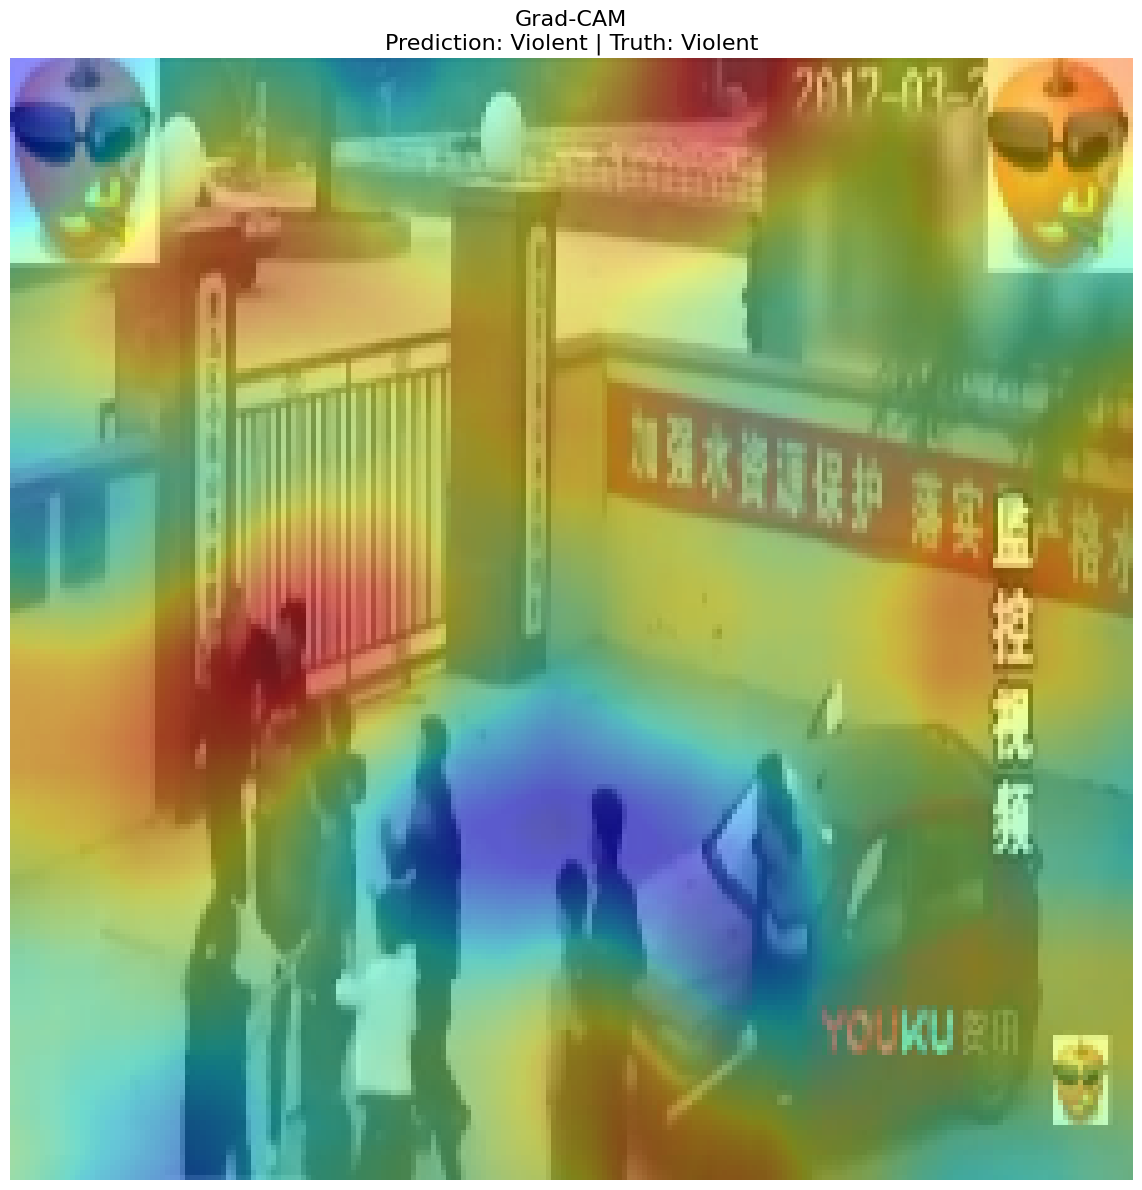

In [8]:
# plot single frame
frame_index = 0  # Change this index to visualize different frames
plot_single_frame_gradcam(heatmap, rgb_frames,frame_index, label, prediction, alpha=0.45)

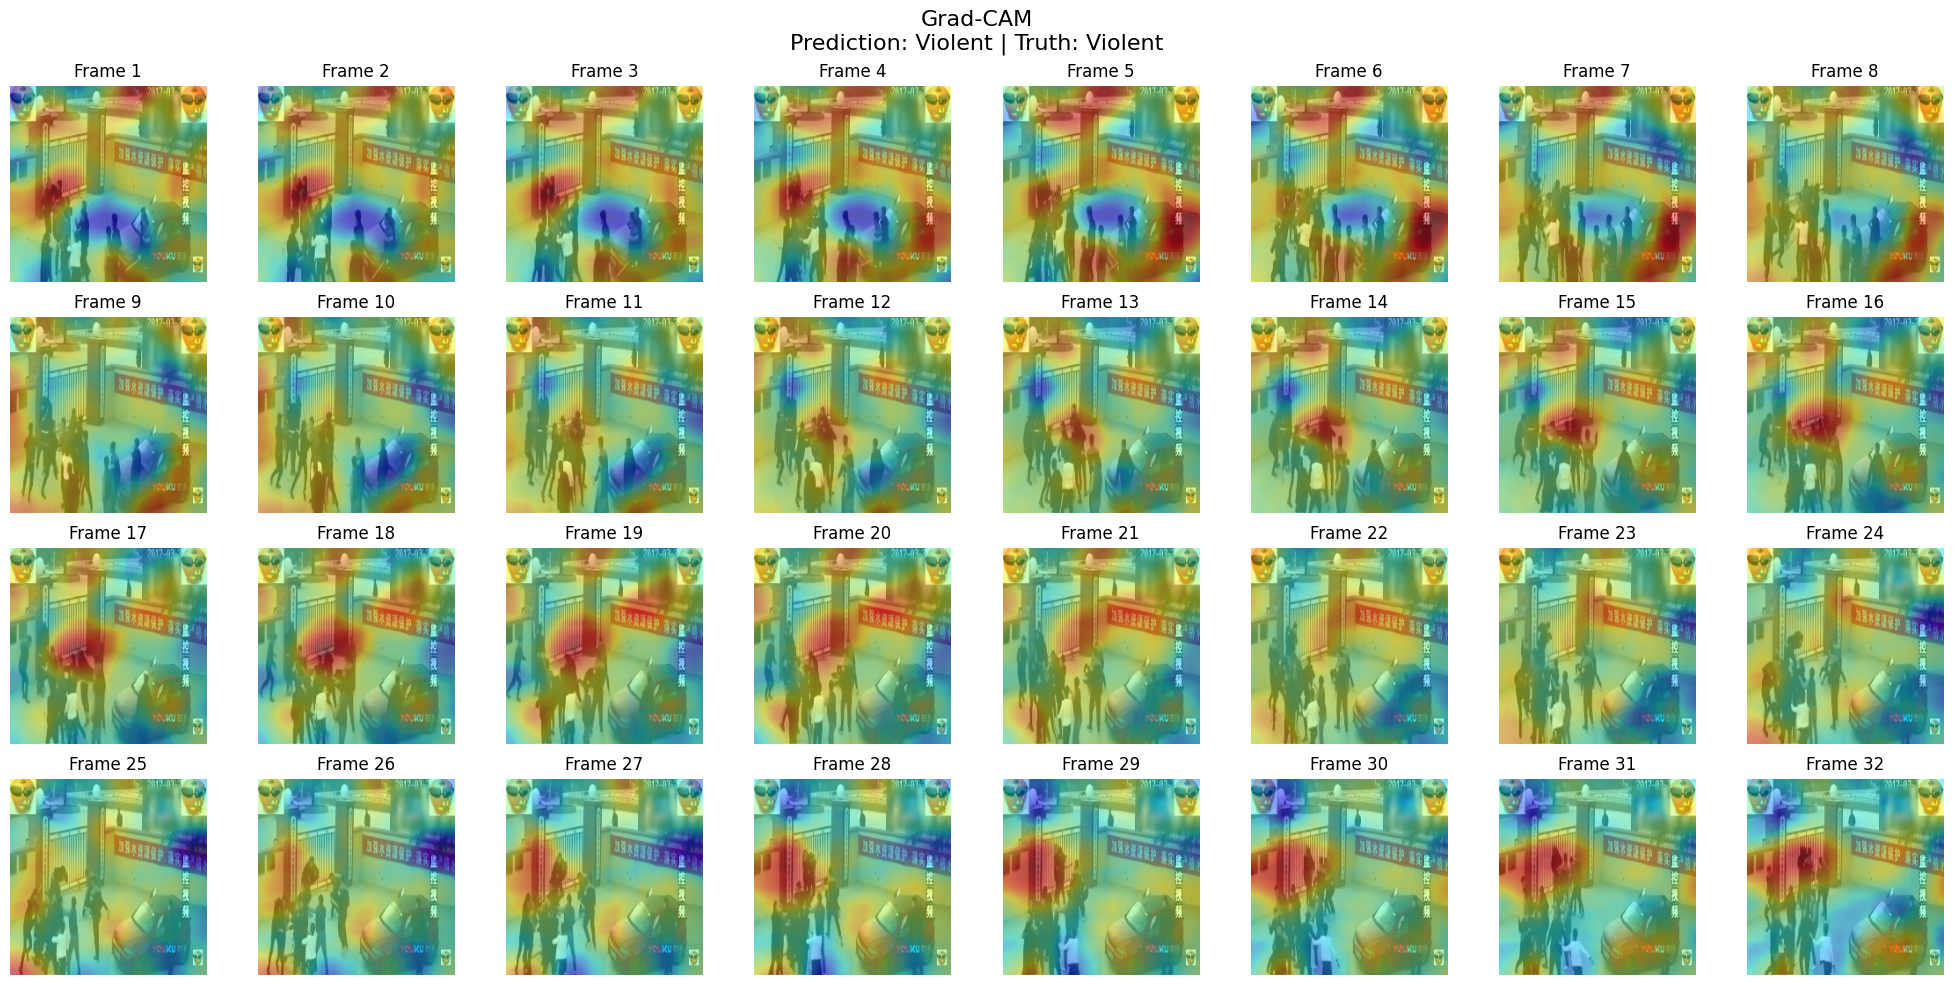

In [9]:
# plot all frames
plot_gradcam_over_rgb(heatmap, rgb_frames, label, prediction, alpha=0.45)

In [ ]:
# plot video
animation = animate_saliency_over_rgb(heatmap, rgb_frames, label, prediction)
HTML(animation.to_jshtml())


<Axes: xlabel='Fraction of locations perturbed', ylabel='Target class probability'>

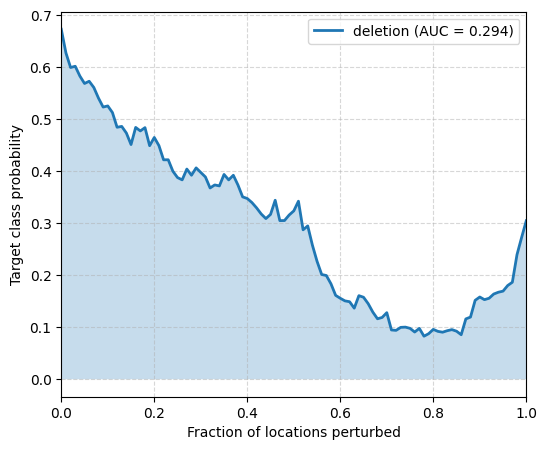

In [10]:
from src.XAI.insertion_deletion_auc import AUC_TEST
auc_test = AUC_TEST(model=model,data_type="image")
fractions, scores, auc = auc_test.deletion(video_batch, saliency_map=heatmap)
AUC_TEST.plot_auc_curve(fractions, scores, auc, "deletion")